# 02 - Data Cleaning
## Airbnb Price Prediction - Austin, TX

**Purpose of this notebook**  
Transform the raw `listings.csv.gz` into a clean, analysis-ready dataset.  
Every decision follows the **"diagnosis then action"** principle: the *why* is always explained before any code is written.

**What this notebook does NOT do**  
- No feature engineering (handled in `03_Features.ipynb`)  
- No encoding or scaling (handled in `04_Preprocessing.ipynb`)  
- No use of the test set (not yet created)

**Snapshot**  
> Inside Airbnb - Austin, TX. Date: 16 September, 2025 Source: http://insideairbnb.com/get-the-data

**Outline**
1. Imports and Setup
2. Load Data
3. Immediate Drops
4. Price Cleaning
5. Review Scores
6. Property Size
7. Bathrooms
8. Host Columns
9. Boolean Columns
10. Final Report and Export

## 1. Imports and Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)

RAW_PATH = '../data/raw/Austin/listings.csv.gz'
PROCESSED_PATH = '../data/processed/data_cleaned.parquet'

## 2. Load Data

In [2]:
df = pd.read_csv(RAW_PATH, low_memory=False)

print(f'Loaded listings.csv {df.shape[0]:,} rows x {df.shape[1]} columns')

Loaded listings.csv 10,533 rows x 79 columns


In [3]:
df.dtypes.value_counts()

str        33
float64    25
int64      21
Name: count, dtype: int64

In [4]:
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
missing_pct = (missing / len(df) * 100).round(2)

pd.DataFrame({'missing_count': missing, 'missing_pct': missing_pct})

,missing_count,missing_pct
license,10533,100.00
calendar_updated,10533,100.00
neighbourhood_group_cleansed,10533,100.00
neighbourhood,5173,49.11
neighborhood_overview,5173,49.11
host_about,3575,33.94
host_location,1875,17.80
review_scores_cleanliness,1624,15.42
review_scores_checkin,1624,15.42
review_scores_value,1624,15.42


**Observations**
- 3 columns are 100% missing (`license`, `calendar_updated`, `neighbourhood_group_cleansed`) → drop immediately
- All 6 review score columns share an identical 15.42% missing rate → these are the same 1,624 listings that have never received a review. This is structured missingness, not random → requires a dedicated strategy in section 5
- `host_response_rate` and `host_acceptance_rate` are missing for ~5-8% of hosts → median imputation in section 8
- `price` has 16 missing rows (0.15%) → drop in section 4
- `estimated_revenue_l365d` is present → leakage risk, must be dropped before any modelling

## 3. Immediate Drops

Three categories of columns are dropped before any other transformation:

- **100% missing**: `license`, `calendar_updated`, `neighbourhood_group_cleansed` carry zero information
- **Free text**: `name`, `description`, `neighborhood_overview`, `host_about` require NLP, out of scope for v1
- **IDs and URLs**: `id`, `listing_url`, `host_url`, `picture_url`, `host_thumbnail_url`, `host_picture_url` are identifiers with no predictive value
- **Redundant geography**: `neighbourhood` is 49% missing and replaced by `neighbourhood_cleansed`
- **Leakage risk**: `estimated_revenue_l365d` and `estimated_occupancy_l365d` are derived from future booking data, using them would leak information that would not be available at prediction time

In [5]:
cols_to_drop = [
    # 100% missing
    'license', 'calendar_updated', 'neighbourhood_group_cleansed',
    # Free text
    'name', 'description', 'neighborhood_overview', 'host_about',
    # IDs and URLs
    'id', 'listing_url', 'host_url', 'picture_url',
    'host_thumbnail_url', 'host_picture_url',
    # Redundant geography
    'neighbourhood',
    # Leakage risk
    'estimated_revenue_l365d', 'estimated_occupancy_l365d'
]

rows_before = df.shape[0]
cols_before = df.shape[1]

df.drop(columns=cols_to_drop, inplace=True)

print(f"Columns dropped : {cols_before} → {df.shape[1]} ({cols_before - df.shape[1]} removed)")
print(f"Rows unchanged  : {df.shape[0]:,}")

Columns dropped : 79 → 63 (16 removed)
Rows unchanged  : 10,533


## 4. Price Cleaning

**Diagnosis**
The `price` column is stored as a string (`"$150.00"`), unusable as-is for modelling.
Three issues identified in the EDA:
- 16 missing values (0.15%)
- 1 listing below $10, likely a data entry error
- 101 listings above $2,500 (P99 threshold), including one extreme outlier at $50,000

**Action**
1. Strip `$` and `,` and convert to float
2. Drop missing prices
3. Drop prices below $10
4. Cap prices above $2,500 at $2,500 (winsorisation) which preserves the signal that these are expensive listings without letting extreme outliers distort the model

**Modelling target**: `log1p(price)` will be used as the model target in `04_Preprocessing.ipynb`.
The log transform reduces skewness from 15.31 to 1.61 and makes the distribution approximately bell-shaped.
We visualise it here for confirmation but do not apply it to the dataframe, that transformation belongs in 04.

In [6]:
rows_before = df.shape[0]

# Convert price string to float
df['price'] = df['price'].str.replace('$', '', regex=False).str.replace(',', '', regex=False).astype(float)

# Drop missing
df = df[df['price'].notna()]
print(f"Dropped missing prices     : {rows_before - df.shape[0]} rows")

# Drop below $10
n = df.shape[0]
df = df[df['price'] >= 10]
print(f"Dropped prices < $10       : {n - df.shape[0]} rows")

# Cap above $2,500
n_capped = (df['price'] > 2500).sum()
df['price'] = df['price'].clip(upper=2500)
print(f"Capped prices > $2,500     : {n_capped} rows")

print(f"\nRows remaining: {df.shape[0]:,}")
print(f"Price range: ${df['price'].min():.0f} — ${df['price'].max():,.0f}")
print(f"Median price: ${df['price'].median():.0f}")

Dropped missing prices     : 16 rows
Dropped prices < $10       : 1 rows
Capped prices > $2,500     : 101 rows

Rows remaining: 10,516
Price range: $15 — $2,500
Median price: $135


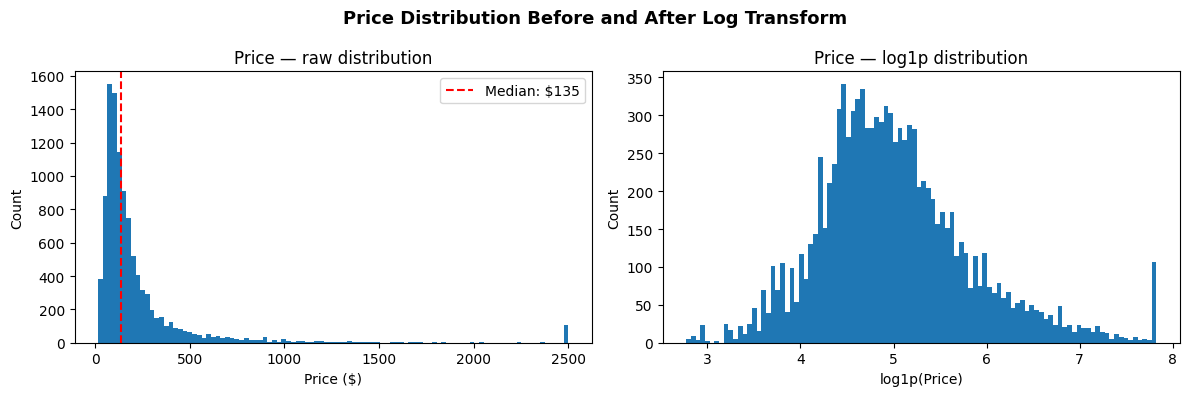

Skewness raw     : 4.69
Skewness log1p   : 0.75


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df['price'], bins=100, edgecolor='none')
axes[0].set_title('Price — raw distribution')
axes[0].set_xlabel('Price ($)')
axes[0].set_ylabel('Count')
axes[0].axvline(df['price'].median(), color='red', linestyle='--', label=f"Median: ${df['price'].median():.0f}")
axes[0].legend()

axes[1].hist(np.log1p(df['price']), bins=100, edgecolor='none')
axes[1].set_title('Price — log1p distribution')
axes[1].set_xlabel('log1p(Price)')
axes[1].set_ylabel('Count')

plt.suptitle('Price Distribution Before and After Log Transform', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"Skewness raw     : {df['price'].skew():.2f}")
print(f"Skewness log1p   : {np.log1p(df['price']).skew():.2f}")

**Observations**
- Raw distribution: skewness = 4.69, heavily right-skewed with a long tail
- log1p distribution: skewness = 0.75, approximately bell-shaped
- The small spike at the right end of the log1p plot (~7.8) is the artificial mass created by capping 101 listings at $2,500 — expected and acceptable
- `log1p(price)` is confirmed as the modelling target. The transform will be applied in `04_Preprocessing.ipynb`, not here

## 5. Review Scores

**Diagnosis**
The EDA identified that all 6 review score columns share an identical 15.42% missing rate,
corresponding to exactly 1,624 listings. These are listings that have never received a review.
This is structured missingness, not random and requires a dedicated strategy.

Imputing with the global median would erase a meaningful signal: a listing with no reviews
behaves differently from a listing with a 4.8 rating.

**Action**
1. Create a `has_reviews` binary flag before any imputation (1 if the listing has at least one review, 0 otherwise)
2. Impute missing review scores with the median computed on reviewed listings only
3. Keep only `review_scores_rating`, the 5 sub-scores are highly correlated with it (r up to 0.79) and add noise without adding signal
4. Drop the 5 sub-scores and date columns (`first_review`, `last_review`, `reviews_per_month`)

In [8]:
df['has_reviews'] = (df['number_of_reviews'] > 0).astype(int)
print(f"Listings with reviews    : {df['has_reviews'].sum():,} ({df['has_reviews'].mean()*100:.1f}%)")
print(f"Listings without reviews : {(df['has_reviews'] == 0).sum():,} ({(df['has_reviews'] == 0).mean()*100:.1f}%)")

Listings with reviews    : 8,900 (84.6%)
Listings without reviews : 1,616 (15.4%)


In [9]:
review_cols = [
    'review_scores_rating', 'review_scores_accuracy', 'review_scores_cleanliness',
    'review_scores_checkin', 'review_scores_communication',
    'review_scores_location', 'review_scores_value'
]

reviewed_mask = df['has_reviews'] == 1

for col in review_cols:
    median_val = df.loc[reviewed_mask, col].median()
    df.loc[reviewed_mask, col] = df.loc[reviewed_mask, col].fillna(median_val)

cols_to_drop = [
    'review_scores_accuracy', 'review_scores_cleanliness',
    'review_scores_checkin', 'review_scores_communication',
    'review_scores_location', 'review_scores_value',
    'first_review', 'last_review', 'reviews_per_month'
]

df.drop(columns=cols_to_drop, inplace=True)

print(f"Missing review_scores_rating on reviewed listings : {df.loc[reviewed_mask, 'review_scores_rating'].isnull().sum()}")
print(f"Missing review_scores_rating on unreviewed listings : {df.loc[~reviewed_mask, 'review_scores_rating'].isnull().sum()}")
print(f"Columns remaining: {df.shape[1]}")

Missing review_scores_rating on reviewed listings : 0
Missing review_scores_rating on unreviewed listings : 1616
Columns remaining: 55


**Observations**
- `has_reviews` flag created: 84.6% of listings have at least one review
- Missing review scores imputed with median on reviewed listings only, unreviewed listings intentionally keep NaN
- 5 sub-scores dropped: high correlation with `review_scores_rating` (r up to 0.79) adds noise without signal
- `first_review`, `last_review`, `reviews_per_month` dropped: date columns will be reconstructed as engineered features in `03_Features.ipynb`

## 6. Property Size

**Diagnosis**
Three columns describe the physical size of a listing:
- `accommodates`: no missing values
- `bedrooms`: 13 missing values (0.12%)
- `beds`: 9 missing values (0.09%)

Both missing rates are negligible. A simple rule-based imputation is acceptable.

**Action**
- Impute missing `bedrooms` using `floor(accommodates / 2)` — a studio for 2 people likely has 1 bedroom
- Impute missing `beds` using `accommodates` — worst case assumption: 1 bed per guest

In [10]:
# Impute bedrooms
df['bedrooms'] = df['bedrooms'].fillna(np.floor(df['accommodates'] / 2))

# Impute beds
df['beds'] = df['beds'].fillna(df['accommodates'])

print(f"Missing bedrooms : {df['bedrooms'].isnull().sum()}")
print(f"Missing beds     : {df['beds'].isnull().sum()}")

Missing bedrooms : 0
Missing beds     : 0


## 7. Bathrooms

**Diagnosis**
`bathrooms_text` is a free-text string describing the number of bathrooms:
examples include "1 bath", "1.5 baths", "Half-bath", "Private half-bath".
32 values are missing (0.30%).
The numeric column `bathrooms` exists but has 6 missing values and is less complete.

**Action**
1. Parse `bathrooms_text` into a numeric column `bathrooms_clean`
2. Handle edge cases: "Half-bath" and "Private half-bath" → 0.5
3. Impute the 32 missing values with the median
4. Drop `bathrooms_text` and the original `bathrooms` column

In [11]:
def parse_bathrooms(text):
    if pd.isna(text):
        return np.nan
    text = text.strip().lower()
    if 'half' in text:
        return 0.5
    numbers = re.findall(r'\d+\.?\d*', text)
    if numbers:
        return float(numbers[0])
    return np.nan

import re

df['bathrooms_clean'] = df['bathrooms_text'].apply(parse_bathrooms)

median_bath = df['bathrooms_clean'].median()
df['bathrooms_clean'] = df['bathrooms_clean'].fillna(median_bath)

df.drop(columns=['bathrooms_text', 'bathrooms'], inplace=True)

print(f"Missing bathrooms_clean : {df['bathrooms_clean'].isnull().sum()}")
print(f"Value counts (top 10):\n{df['bathrooms_clean'].value_counts().head(10)}")

Missing bathrooms_clean : 0
Value counts (top 10):
bathrooms_clean
1.0    5284
2.0    2418
2.5     884
3.0     594
1.5     514
3.5     265
4.0     192
4.5      87
5.0      69
0.0      56
Name: count, dtype: int64


**Observations**
- `bathrooms_text` parsed successfully into a numeric column `bathrooms_clean`
- 32 missing values imputed with median (1.0)
- 56 listings show 0 bathrooms which is plausible for shared facilities, kept as-is
- Distribution is coherent: majority of listings have 1 or 2 bathrooms

## 8. Host Columns

**Diagnosis**
Several host columns need attention before they can be used in a model.

`host_is_superhost`, `host_identity_verified`, and `host_has_profile_pic` are stored as
the strings `'t'` and `'f'`, pandas reads them as object columns, not booleans.
A model cannot do arithmetic on `'t'` and `'f'`, so we need to convert them to proper
boolean values (True/False). Missing values in `host_is_superhost` are treated as False:
if Airbnb has no record of superhost status, the safest assumption is that the host is not one.

`host_response_rate` and `host_acceptance_rate` are stored as percentage strings like `"97%"`.
We need to strip the `%` sign and convert to a float between 0 and 100.
Both have missing values (~5-8%) — we will impute with the median computed on non-missing rows.

`host_since` is a date string. We will not parse it here, the feature engineering notebook
(03_Features.ipynb) will convert it to a seniority in days, which is more meaningful for a model.

**Action**
1. Convert `host_is_superhost`, `host_identity_verified`, `host_has_profile_pic` from `'t'`/`'f'` to boolean
2. Convert `host_response_rate` and `host_acceptance_rate` from percentage strings to float
3. Impute missing `host_response_rate` and `host_acceptance_rate` with their respective medians

In [12]:
# Convert 't'/'f' to  booleans
# NaN in host_is_superhost is treated as False
bool_host_cols = ['host_is_superhost', 'host_identity_verified', 'host_has_profile_pic']

for col in bool_host_cols:
    df[col] = df[col].map({'t': True, 'f': False}).fillna(False)

# Convert percentage strings to float
for col in ['host_response_rate', 'host_acceptance_rate']:
    df[col] = df[col].str.replace('%', '', regex=False).astype(float)
    median_val = df[col].median()
    df[col] = df[col].fillna(median_val)
    print(f"{col} missing after imputation: {df[col].isnull().sum()} | median used: {median_val:.1f}%")

# Verify boolean conversions
print(f"\nhost_is_superhost value counts:\n{df['host_is_superhost'].value_counts()}")

host_response_rate missing after imputation: 0 | median used: 100.0%
host_acceptance_rate missing after imputation: 0 | median used: 99.0%

host_is_superhost value counts:
host_is_superhost
False    5341
True     5175
Name: count, dtype: int64


**Observations**
- `host_is_superhost`, `host_identity_verified`, `host_has_profile_pic` successfully converted to booleans
- Nearly half of hosts are superhosts (49.1%) reflects the high proportion of professional hosts in Austin
- `host_response_rate` and `host_acceptance_rate` converted from percentage strings to float and imputed with their respective medians (100% and 99%)
- The high medians suggest that missing values come from inactive or new hosts, not unresponsive ones, median imputation is conservative but acceptable for v1
- `host_since` is left as-is: it will be converted to a seniority in days in `03_Features.ipynb`

## 9. Boolean Columns

**Diagnosis**
`instant_bookable` follows the same pattern as the host boolean columns seen in section 8:
it is stored as the strings `'t'` and `'f'` instead of proper Python booleans.
This column indicates whether a guest can book the listing immediately without waiting
for host approval is a potentially useful signal for pricing since instant bookable listings
may be priced differently to attract more bookings.

**Action**
Convert `instant_bookable` from `'t'`/`'f'` to boolean using the same mapping as section 8.
No missing values were identified in the EDA so no imputation is needed.

In [13]:
# Convert instant_bookable from 't'/'f' 
df['instant_bookable'] = df['instant_bookable'].map({'t': True, 'f': False})

print(f"instant_bookable value counts:\n{df['instant_bookable'].value_counts()}")
print(f"Missing values: {df['instant_bookable'].isnull().sum()}")

instant_bookable value counts:
instant_bookable
False    6203
True     4313
Name: count, dtype: int64
Missing values: 0


**Observations**
- `instant_bookable` successfully converted to boolean — no missing values
- 41% of listings are instantly bookable — a meaningful split that may carry a pricing signal
- This feature will be used as-is in modelling: no further transformation needed

## 10. Final Report and Export

Before saving, we print a full cleaning report to document every transformation applied
in this notebook. This serves two purposes: transparency for anyone reading the notebook,
and a sanity check that no step produced unexpected results.

**Why Parquet and not CSV?**
We save the cleaned dataset as a `.parquet` file rather than a CSV for two reasons.
First, Parquet is a binary columnar format, it reads 5-10x faster than CSV and produces
a file 3-5x smaller. Second, and more importantly for our pipeline, Parquet preserves
column types. Every boolean we carefully converted in sections 8 and 9, every float we
parsed from a string, all of it is stored in the file and restored exactly on reload.
With a CSV, pandas would read everything back as strings and `03_Features.ipynb` would
need to redo all those conversions.

In [14]:
print("=" * 55)
print("CLEANING REPORT")
print("=" * 55)

print(f"\nRows")
print(f"  Original        : 10,533")
print(f"  After cleaning  : {df.shape[0]:,}")
print(f"  Dropped         : {10533 - df.shape[0]:,} ({(10533 - df.shape[0]) / 10533 * 100:.1f}%)")

print(f"\nColumns")
print(f"  Original        : 79")
print(f"  After cleaning  : {df.shape[1]}")
print(f"  Dropped         : {79 - df.shape[1]}")

print(f"\nDrops breakdown")
print(f"  Missing price            : 16 rows")
print(f"  Price below $10          : 1 row")
print(f"  Capped above $2,500      : 101 rows (kept, value capped)")

print(f"\nRemaining missing values")
missing_remaining = df.isnull().sum()
missing_remaining = missing_remaining[missing_remaining > 0]
if len(missing_remaining) == 0:
    print("  None except review_scores_rating on unreviewed listings (intentional)")
else:
    for col, n in missing_remaining.items():
        print(f"  {col}: {n}")

print(f"\nColumn types")
print(df.dtypes.value_counts().to_string())

print("=" * 55)

CLEANING REPORT

Rows
  Original        : 10,533
  After cleaning  : 10,516
  Dropped         : 17 (0.2%)

Columns
  Original        : 79
  After cleaning  : 54
  Dropped         : 25

Drops breakdown
  Missing price            : 16 rows
  Price below $10          : 1 row
  Capped above $2,500      : 101 rows (kept, value capped)

Remaining missing values
  host_name: 9
  host_since: 9
  host_location: 1858
  host_response_time: 851
  host_neighbourhood: 834
  host_listings_count: 9
  host_total_listings_count: 9
  host_verifications: 9
  minimum_minimum_nights: 6
  maximum_minimum_nights: 6
  minimum_maximum_nights: 6
  maximum_maximum_nights: 6
  has_availability: 85
  review_scores_rating: 1616

Column types
int64      20
float64    17
str        13
object      3
bool        1


In [15]:
import os

os.makedirs('../data/processed', exist_ok=True)
df.to_parquet(PROCESSED_PATH, index=False)

print(f"Saved: {PROCESSED_PATH}")
print(f"Shape: {df.shape[0]:,} rows x {df.shape[1]} columns")

Saved: ../data/processed/data_cleaned.parquet
Shape: 10,516 rows x 54 columns


**Report commentary**
- 17 rows dropped (0.2% of the dataset) - negligible data loss
- 25 columns removed: IDs, URLs, free text, 100% missing columns, and leakage risks
- Remaining missing values fall into two categories. First, `review_scores_rating` has 1,616 NaN values - this is intentional and carries a signal (unreviewed listings). Second, host columns such as `host_location`, `host_response_time`, and `host_neighbourhood` have residual missingness that will be resolved in `03_Features.ipynb` when we decide which of these columns to keep
- 13 string and 3 object columns remain - these are legitimate categorical variables (`room_type`, `property_type`, `neighbourhood_cleansed`, etc.) that will be encoded in `04_Preprocessing.ipynb`
- The dataset is saved as Parquet: all boolean and numeric types are preserved on reload, making `03_Features.ipynb` immediately operational without any re-conversion